In [1]:
import numpy as np
import pandas as pd
import random

from scipy import stats
from scipy.stats import bernoulli
from matplotlib import pyplot as plt

SAMPLE_SIZE = 1000
SEED = 32

In [2]:
random.seed(SEED)
np.random.seed(SEED)

## Experimental data

### Data generation process (Synthetic)

In [3]:
def generate_sample(
        female: bool,
        treatment: bool,
        is_rct: bool,
        sample_size: int,
        binom_parameter: float,
    ) -> np.ndarray:
    """Generates sample based on ground truth."""
    outcomes = bernoulli(binom_parameter).rvs(sample_size)
    return np.hstack(
        [
        np.repeat(int(female), sample_size).reshape(-1, 1),
        np.repeat(int(is_rct), sample_size).reshape(-1, 1),
        np.repeat(int(treatment), sample_size).reshape(-1, 1),
        outcomes.reshape(-1, 1),
        ]
    )

In [4]:
data_male_drug = generate_sample(False, True, True, SAMPLE_SIZE, 0.49)
data_male_control = generate_sample(False, False, True, SAMPLE_SIZE, 0.21)
data_female_drug = generate_sample(True, True, True, SAMPLE_SIZE, 0.49)
data_female_control = generate_sample(True, False, True, SAMPLE_SIZE, 0.21)

In [5]:
data_male_control

array([[0, 1, 0, 0],
       [0, 1, 0, 0],
       [0, 1, 0, 0],
       ...,
       [0, 1, 0, 0],
       [0, 1, 0, 0],
       [0, 1, 0, 0]], shape=(1000, 4))

In [6]:
df = pd.DataFrame(np.vstack([
    data_male_drug,
    data_male_control,
    data_female_drug,
    data_female_control,
]), columns=["sex", "is_rct", "treatment", "outcome"])

In [7]:
df.sample(10)

,sex,is_rct,treatment,outcome
1362,0,1,0,0
3754,1,1,0,0
518,0,1,1,0
2798,1,1,1,0
2055,1,1,1,1
2216,1,1,1,1
1822,0,1,0,0
2887,1,1,1,0
2039,1,1,1,0
871,0,1,1,0


### Experiment results

In [8]:
agg_df = df.groupby(["sex", "treatment", "is_rct"]).agg("mean").unstack(level=1)
agg_df

outcome       
treatment        0      1
sex is_rct               
0   1        0.228  0.499
1   1        0.206  0.484

In [9]:
agg_df["CATE"] = agg_df[("outcome", 1)] - agg_df[("outcome", 0)]
agg_df

outcome          CATE
treatment        0      1       
sex is_rct                      
0   1        0.228  0.499  0.271
1   1        0.206  0.484  0.278

### Statistical significance tests
(for cases where data generation was not synthetic)

In [10]:
# Estimate Binomial parameters (outcome is the last column)
p_hat_m_control = data_male_control[:, -1].mean()
p_hat_m_drug = data_male_drug[:, -1].mean()
p_hat_f_control = data_female_control[:, -1].mean()
p_hat_f_drug = data_female_drug[:, -1].mean()

# Compute CATEs
delta_m  = p_hat_m_drug - p_hat_m_control
delta_f  = p_hat_f_drug - p_hat_f_control

# Compute variances
var_delta_m = (
    (p_hat_m_control * (1-p_hat_m_control) / SAMPLE_SIZE)
    + (p_hat_m_drug * (1-p_hat_m_drug) / SAMPLE_SIZE)
)

var_delta_f = (
    (p_hat_f_control * (1-p_hat_f_control) / SAMPLE_SIZE)
    + (p_hat_f_drug * (1-p_hat_f_drug) / SAMPLE_SIZE)
)

# H0: delta_m == delta_f (the treatment effect is the same for males and females)
# H1: delta_m != delta_f (the treatment effect differs between sexes; two-sided test)
z_stat = (delta_m - delta_f) / np.sqrt(var_delta_m + var_delta_f)

p_value = 2 * (1 - stats.norm.cdf(np.abs(z_stat)))
print(f"Z-statistic: {z_stat:.4f}, p-value: {p_value:.4f}")

Z-statistic: -0.2416, p-value: 0.8091


In [11]:
assert (p_value > 0.05)

### Experimental conclusion

In [12]:
male_cate = p_hat_m_drug - p_hat_m_control
female_cate = p_hat_f_drug - p_hat_f_control
ate_hat = np.array(
    [male_cate, female_cate]
).mean()

In [13]:
print(f"The drug increases the recovery rate by {(ate_hat)*100:.2f}%")

The drug increases the recovery rate by 27.45%


In [14]:
def plot_results(
    p_hat_m_control: float,
    p_hat_m_drug: float,
    p_hat_f_control: float,
    p_hat_f_drug: float
):
    plt.style.use('ggplot')
    subpopulation = ("control", "treatment")
    covariates = {
        'female': (p_hat_f_control, p_hat_f_drug),
        'male': (p_hat_m_control, p_hat_m_drug),
        'average': (
            np.array([p_hat_f_control, p_hat_m_control]).mean(),
            np.array([p_hat_f_drug, p_hat_m_drug]).mean()
        ),
    }

    x = np.arange(len(subpopulation))*.7  # the label locations
    width = 0.15  # the width of the bars
    multiplier = 0

    fig, ax = plt.subplots(layout='constrained')

    for attribute, measurement in covariates.items():
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute)
        ax.bar_label(
            rects,
            fmt=lambda x: f'{x*100:.0f}%',
            padding=3
        )
        multiplier += 1

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel('survival rate')
    ax.set_title('Treatment effect by subpopulation')
    ax.set_xticks(x + width, subpopulation)
    ax.legend(loc='upper left', ncols=3)
    ax.set_ylim(0, 1)
    fig.set_size_inches(5, 5)
    plt.show()
    return None

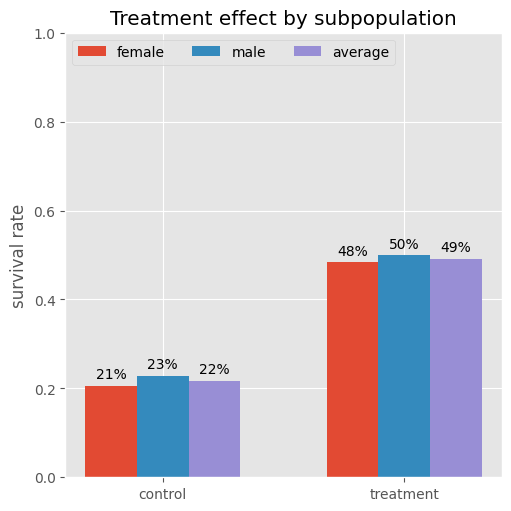

In [15]:
plot_results(
    p_hat_m_control,
    p_hat_m_drug,
    p_hat_f_control,
    p_hat_f_drug
)

In [16]:
print(
    "It thus appears reasonable to conclude that the drug \n"
    "has a net remedial effect on some\n"
    "patients and that every patient, be it male or female, \n"
    "should be advised to take the drug and benefit from\n"
    f"its promise of increasing one’s chances of \n"
    f"recovery {(ate_hat)*100:.2f}%"
)

It thus appears reasonable to conclude that the drug 
has a net remedial effect on some
patients and that every patient, be it male or female, 
should be advised to take the drug and benefit from
its promise of increasing one’s chances of 
recovery 27.45%


## Observational data

### Data generation process (synthetic)

In [17]:
"""
At this point, the drug manufacturer ventured to find out to what degree people actually buy the
approved drug, following its recommended usage. A market survey was conducted (observational study)
and revealed7 that only 70% of men and 70% of women actually chose to take the drug; problems with side
effects and rumors of unexpected deaths may have caused the other 30% to avoid it. A careful examination
of the observational study has further revealed substantial differences in survival rates of men and women
who chose to use the drug (shown in Tables 2 and 3). The rate of recovery among drug-choosing men was
exactly the same as that among the drug-avoiding men (70% for each), but the rate of recovery among
drug-choosing women was 43% lower than among drug-avoiding women (0.27 vs 0.70, in Table 2). It appears
as though many women who chose the drug were already in an advanced stage of the disease, which may
account for their low recovery rate of 27%.
"""

@np.vectorize()
def sample_male_obs(placeholder=None):
    chooses_treatment = bernoulli(0.7).rvs(1).item()
    if chooses_treatment:
        survival = bernoulli(0.7).rvs(1).item()
    else:
        survival = bernoulli(0.7).rvs(1).item()
    return chooses_treatment, survival

@np.vectorize()
def sample_female_obs(placeholder=None):
    chooses_treatment = bernoulli(0.7).rvs(1).item()
    if chooses_treatment:
        survival = bernoulli(0.27).rvs(1).item()
    else:
        survival = bernoulli(0.7).rvs(1).item()
    return chooses_treatment, survival



def generate_sample(
        female: bool,
        treatment: bool,
        is_rct: bool,
        sample_size: int,
        binom_parameter: float = None,
    ) -> np.ndarray:
    """Generates sample based on ground truth."""

    if is_rct:
        outcomes = bernoulli(binom_parameter).rvs(sample_size)
        return np.hstack(
            [
            np.repeat(int(female), sample_size).reshape(-1, 1),
            np.repeat(int(is_rct), sample_size).reshape(-1, 1),
            np.repeat(int(treatment), sample_size).reshape(-1, 1),
            outcomes.reshape(-1, 1),
            ]
        )
    else:
        if female:
            choices, outcomes = sample_female_obs(np.repeat(1, sample_size))
        else:
            choices, outcomes = sample_male_obs(np.repeat(1, sample_size))
        return np.hstack(
            [
            np.repeat(int(female), sample_size).reshape(-1, 1),
            np.repeat(int(is_rct), sample_size).reshape(-1, 1),
            choices.reshape(-1, 1),
            outcomes.reshape(-1, 1),
            ]
        )

In [18]:
obs_male = generate_sample(False, None, False, SAMPLE_SIZE*2)
obs_female = generate_sample(True, None, False, SAMPLE_SIZE*2)

### Observed Results

In [19]:
df_obs = pd.DataFrame(np.vstack([
    obs_male,
    obs_female,
]), columns=["sex", "is_rct", "treatment", "outcome"])
df_obs.sample(10)

,sex,is_rct,treatment,outcome
2337,1,0,1,1
2622,1,0,1,1
1508,0,0,1,1
1279,0,0,1,0
2352,1,0,1,1
3723,1,0,1,1
3231,1,0,1,0
3077,1,0,1,0
1155,0,0,0,0
1195,0,0,1,0


In [20]:
df_obs.groupby(["sex", "treatment", "is_rct"]).agg("mean")

outcome
sex treatment is_rct          
0   0         0       0.713592
    1         0       0.670043
1   0         0       0.687097
    1         0       0.277536

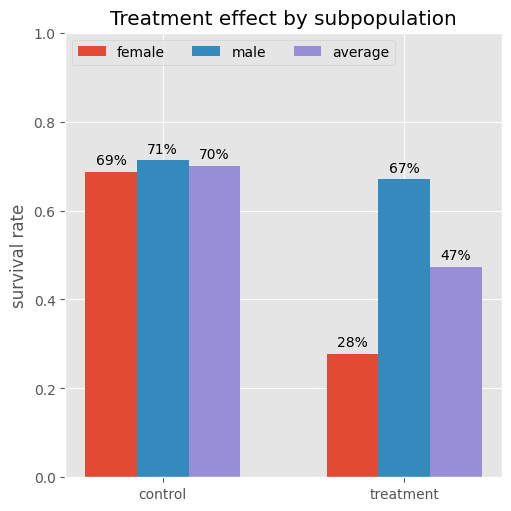

In [21]:
plot_results(
    df_obs.query(
        "sex == 0 and treatment == 0 and is_rct == 0"
        )["outcome"].mean(),
    df_obs.query(
        "sex == 0 and treatment == 1 and is_rct == 0"
        )["outcome"].mean(),
    df_obs.query(
        "sex == 1 and treatment == 0 and is_rct == 0"
        )["outcome"].mean(),
    df_obs.query(
        "sex == 1 and treatment == 1 and is_rct == 0"
        )["outcome"].mean(),
)

## Estimate P(benefit) & P(harm)

At this point, having data from both experimental and observational studies we can
estimate the probability


$P(\text{ITE}(u) > 0 \mid C(u) = c) = P(\text{benefit} \mid C(u) = c)$


for both a typical male and a typical female. Quantitative analysis shows (see Section 4 from Mueller and Pearl's paper)
that, with the data above, the drug affects males markedly differently from the way it
affects females.

Let's combine both experimental and observational data to calculate P(benefit).
In this case, it is possible to get point estimates for both females and males.

### P(benefit|female)

In [22]:
# Lower bond is defined by the maximuum between:
# 0,
# P(Yt) - P(Yc)
# P(y) - P (Yc)
# P(Yt) - P(y)

p_yt_female = df\
    .query("treatment == 1 and is_rct == 1 and sex == 1")["outcome"].mean()
p_yc_female = df\
    .query("treatment == 0 and is_rct == 1 and sex == 1")["outcome"].mean()
p_y_female = df_obs\
    .query("is_rct == 0 and sex == 1")["outcome"].mean()


print("Lower terms: ", [
    0,
    p_yt_female - p_yc_female,
    p_y_female - p_yc_female,
    p_yt_female - p_y_female
])

lower_bond = np.max([
    0,
    p_yt_female - p_yc_female,
    p_y_female - p_yc_female,
    p_yt_female - p_y_female
])

Lower terms:  [0, np.float64(0.278), np.float64(0.19850000000000004), np.float64(0.07949999999999996)]


In [23]:
# Upper bond is defined by the minimum between:
# P(Yt)
# P(y'c)
# P(t, y) + P(c, y'),
# P(yt) - P(yc) + P(t, y') + P(c, y)

# Compute the probabilities
p_not_yc_female = 1 - p_yc_female
p_t_and_y_female = (
    df_obs.query("is_rct == 0 and sex == 1")["treatment"].mean()
    * df_obs.query(
        "treatment == 1 and is_rct == 0 and sex == 1"
        )["outcome"].mean()
)
p_c_and_not_y_female = (
    (1 - df_obs.query("is_rct == 0 and sex == 1")["treatment"].mean())
    * (1 - df_obs.query("treatment == 0 and is_rct == 0 and sex == 1")["outcome"].mean())
)
p_t_and_not_y_female = (
    df_obs.query("is_rct == 0 and sex == 1")["treatment"].mean()
    * (1 - df_obs.query("treatment == 1 and is_rct == 0 and sex == 1")["outcome"].mean())
)
p_c_and_y_female = (
    (1 - df_obs.query("is_rct == 0 and sex == 1")["treatment"].mean())
    * df_obs.query("treatment == 0 and is_rct == 0 and sex == 1")["outcome"].mean()
)

print("Upper terms: ", [
    p_yt_female,
    p_not_yc_female,
    p_t_and_y_female + p_c_and_not_y_female,
    p_yt_female - p_yc_female + p_t_and_not_y_female + p_c_and_y_female
])

upper_bond = np.min([
    p_yt_female,
    p_not_yc_female,
    p_t_and_y_female + p_c_and_not_y_female,
    p_yt_female - p_yc_female + p_t_and_not_y_female + p_c_and_y_female
])

Upper terms:  [np.float64(0.484), np.float64(0.794), np.float64(0.2885), np.float64(0.9895)]


In [24]:
print(f"Lower bond: {lower_bond:.4f}, Upper bond: {upper_bond:.4f}")

e = 0.02
if abs(upper_bond - lower_bond) < e:
    print(f"P(benefit|female) = {upper_bond:.4f}")

else:
    print(
        f"P(benefit|female) is between {lower_bond:.4f} and {upper_bond:.4f}"
    )
p_benefit_female = np.array([lower_bond, upper_bond])

Lower bond: 0.2780, Upper bond: 0.2885
P(benefit|female) = 0.2885


### P(benefit|male)

In [25]:
# Lower bond is defined by the maximuum between:
# 0,
# P(Yt) - P(Yc)
# P(y) - P (Yc)
# P(Yt) - P(y)

p_yt_male = df.query("treatment == 1 and is_rct == 1 and sex == 0")["outcome"].mean()
p_yc_male = df.query("treatment == 0 and is_rct == 1 and sex == 0")["outcome"].mean()
p_y_male = df_obs.query("is_rct == 0 and sex == 0")["outcome"].mean()


print("Lower terms: ", [
    0,
    p_yt_male - p_yc_male,
    p_y_male - p_yc_male,
    p_yt_male - p_y_male
])

lower_bond_male = np.max([
    0,
    p_yt_male - p_yc_male,
    p_y_male - p_yc_male,
    p_yt_male - p_y_male
])

Lower terms:  [0, np.float64(0.271), np.float64(0.4555), np.float64(-0.1845)]


In [26]:
# Upper bond is defined by the minimum between:
# P(Yt)
# P(y'c)
# P(t, y) + P(c, y'),
# P(yt) - P(yc) + P(t, y') + P(c, y)

# Compute the probabilities
p_not_yc_male = 1 - p_yc_male
p_t_and_y_male = (
    df_obs.query("is_rct == 0 and sex == 0")["treatment"].mean()
    * df_obs.query("treatment == 1 and is_rct == 0 and sex == 0")["outcome"].mean()
)
p_c_and_not_y_male = (
    (1 - df_obs.query("is_rct == 0 and sex == 0")["treatment"].mean())
    * (1 - df_obs.query("treatment == 0 and is_rct == 0 and sex == 0")["outcome"].mean())
)
p_t_and_not_y_male = (
    df_obs.query("is_rct == 0 and sex == 0")["treatment"].mean()
    * (1 - df_obs.query("treatment == 1 and is_rct == 0 and sex == 0")["outcome"].mean())
)
p_c_and_y_male = (
    (1 - df_obs.query("is_rct == 0 and sex == 0")["treatment"].mean())
    * df_obs.query("treatment == 0 and is_rct == 0 and sex == 0")["outcome"].mean()
)

print("Upper terms: ", [
    p_yt_male,
    p_not_yc_male,
    p_t_and_y_male + p_c_and_not_y_male,
    p_yt_male - p_yc_male + p_t_and_not_y_male + p_c_and_y_male
])

upper_bond_male = np.min([
    p_yt_male,
    p_not_yc_male,
    p_t_and_y_male + p_c_and_not_y_male,
    p_yt_male - p_yc_male + p_t_and_not_y_male + p_c_and_y_male
])

Upper terms:  [np.float64(0.499), np.float64(0.772), np.float64(0.5515), np.float64(0.7195)]


In [27]:
print(f"Lower bond: {lower_bond_male:.4f}, Upper bond: {upper_bond_male:.4f}")

e = 0.02
if abs(upper_bond_male - lower_bond_male) < e:
    print(f"P(benefit|male) = {upper_bond_male:.4f}")

else:
    print(
        f"P(benefit|male) is between {lower_bond_male:.4f} and {upper_bond_male:.4f}"
    )
p_benefit_male = np.array([lower_bond_male, upper_bond_male])

Lower bond: 0.4555, Upper bond: 0.4990
P(benefit|male) is between 0.4555 and 0.4990


### Calculating P(harm)
"""

A natural question to ask at this point is, under what condition will RCT results constitute a point estimate for our target quantity, $P(\text{benefit})$? Pearl has shown that this occurs under a condition called *monotonicity*, namely, when the treatment cannot harm any individual, formally

$$P(y_t', y_c) = P(\text{harm}) = 0.$$

This can be shown through a general relationship between $P(\text{harm})$, $P(\text{benefit})$, and ATE, which reads:

$$P(\text{harm}) = P(\text{benefit}) - \text{ATE}. \tag{10}$$
"""

In [28]:
p_benefit_female

array([0.278 , 0.2885])

In [29]:
p_harm_female = p_benefit_female - np.repeat(female_cate, 2)
p_harm_male = p_benefit_male - np.repeat(male_cate, 2)

In [30]:
if abs(p_harm_female[0] - p_harm_female[1]) < e:
    print(f"P(harm|female) = {p_harm_female[0]:.4f}")

else:
    print(
        f"P(harm|female) is between {p_harm_female[1]:.4f} and {p_harm_female[0]:.4f}"
    )

P(harm|female) = 0.0000


In [31]:
if abs(p_harm_male[0] - p_harm_male[1]) < e:
    print(f"P(harm|male) = {p_harm_male[0]:.4f}")

else:
    print(
        f"P(harm|male) is between {p_harm_male[1]:.4f} and {p_harm_male[0]:.4f}"
    )

P(harm|male) is between 0.2280 and 0.1845


## Results analysis

In [32]:
# P(harm) and P(benefit) are intervals, so each gets a column per bound,
# next to the RCT recovery rates and the CATE.
from results_analysis.tables import add_bound_columns, style_bounds_table

agg_df = add_bound_columns(
    agg_df,
    p_benefit={0: p_benefit_male, 1: p_benefit_female},
    p_harm={0: p_harm_male, 1: p_harm_female},
)

In [33]:
# Green where the drug cannot harm anyone (P(harm) = 0, females),
# red where it can (P(harm) > 0, males), blue for the experimental CATE it is
# compared against, gold for the P(benefit) bounds.
style_bounds_table(agg_df)

### Summary table

Every number below is estimated from the samples simulated above, not taken
from the numerical example in the paper and not a population quantity. Quantities the data identify — the experimental and
observational rates and the CATE — are reported as point estimates; P(benefit)
and P(harm) are only partially identified, so they are reported as intervals,
which collapse to a point estimate whenever the two bounds agree to within the
tolerance `e` used throughout the notebook.

In [ ]:
from results_analysis.tables import (
    build_summary,
    estimate_subgroups,
    monotonicity,
    style_summary,
)

results = estimate_subgroups(df, df_obs)
monotonic = monotonicity(results, tol=e)
summary = build_summary(results, monotonic, tol=e)
style_summary(summary, monotonic)

,Female,Male,Both sexes
Quantity,,,
P(y_t) — recovery under treatment (RCT),0.484,0.499,0.491
P(y_c) — recovery under control (RCT),0.206,0.228,0.217
P(y) — recovery observed (survey),0.405,0.683,0.544
P(t) — chose the drug (survey),0.690,0.691,0.691
CATE = P(y_t) − P(y_c),0.278,0.271,0.274
P(benefit),0.283,"[0.456, 0.499]","[0.327, 0.420]"
P(harm) = P(benefit) − CATE,0.005 (≈ 0),"[0.184, 0.228]","[0.053, 0.146]"
Monotonicity: P(harm) = 0 ?,yes — P(benefit) = CATE,no — P(benefit) > CATE,no — P(benefit) > CATE


## Three policy scenarios for the males in our sample

The bounds estimated above are not only a table: they say what would happen to
these 2,000 males under three different regimes.

Everything below is an estimate computed from the simulated samples, never a
population quantity. An interval marks a quantity the data only bound (partial
identification), and every number - interval or point - still carries sampling
error on top of that. In a finite sample the two bounds can even cross by a
little, so the shares of the response types are clipped to the $[0, 1]$ they
must lie in and need not add up to the last decimal.

Each regime is read off the four response types, which the bounds pin down
through $P(y_t) = P(benefit) + P(y_t, y_c)$ and
$P(y_c) = P(harm) + P(y_t, y_c)$.

In [34]:
# Shared helpers for the three policy diagrams below.
from results_analysis.scenarios import (
    observational_sample_size,
    plot_biomarker,
    plot_not_approved,
    plot_prescribed_to_all,
    print_response_types,
    response_types,
)

MALE_SAMPLE = observational_sample_size(df_obs, sex=0)

In [35]:
# The bounds estimated above pin down how the sampled males split into the four
# response types (benefit, harm, survive either way, die either way).
male_types = response_types(
    p_yt=p_yt_male,
    p_yc=p_yc_male,
    p_benefit=p_benefit_male,
    p_harm=p_harm_male,
)
print_response_types(male_types, tol=e)

Male response types, estimated from the sample
  benefit (drug saves them):     [0.456, 0.499]
  harm (drug kills them):        [0.184, 0.228]
  survive either way:            [0.000, 0.044]
  die either way:                [0.273, 0.317]


### Scenario 1 - the drug is not approved

Nobody can be treated, so every male in the sample lives out his untreated
outcome and survival is estimated by the experimental control rate $P(y_c)$.
The drug harms no one, but the males it would have saved die anyway - benefit and
harm are both absent because there is no treatment to produce them.

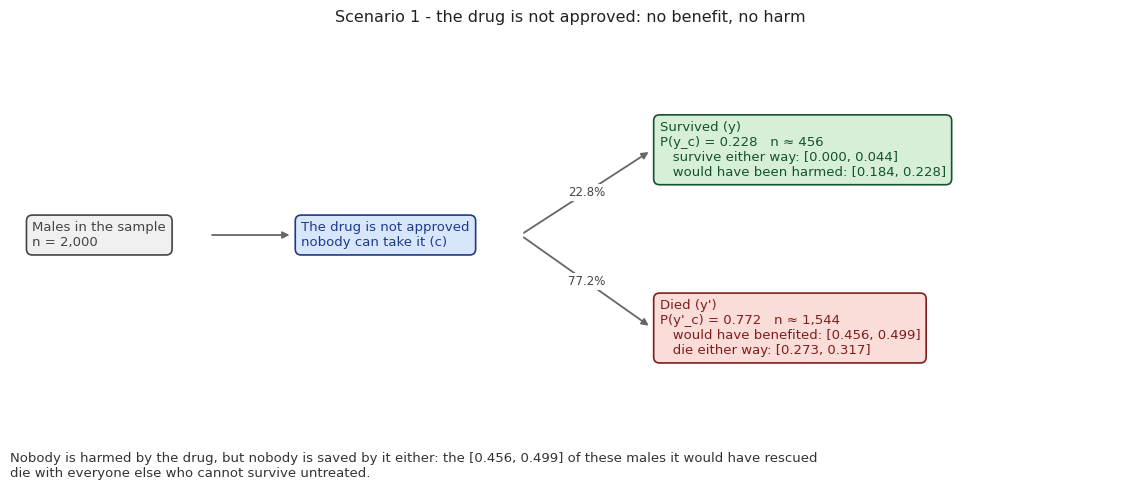

In [127]:
# Scenario 1 - the drug is not approved: every sampled male stays untreated (c).
plot_not_approved(male_types, n=MALE_SAMPLE, tol=e)

### Scenario 2 - the drug is approved and prescribed to everyone

The 2,000 males attend the physician and every one of them is put on the drug,
so survival is estimated by the experimental treatment rate $P(y_t)$. Benefit
and harm are now both realised, and the deaths fall into two very different
groups: the males the drug killed, who would have survived untreated, and the
males who would have died either way. The survival figure alone cannot tell
them apart.

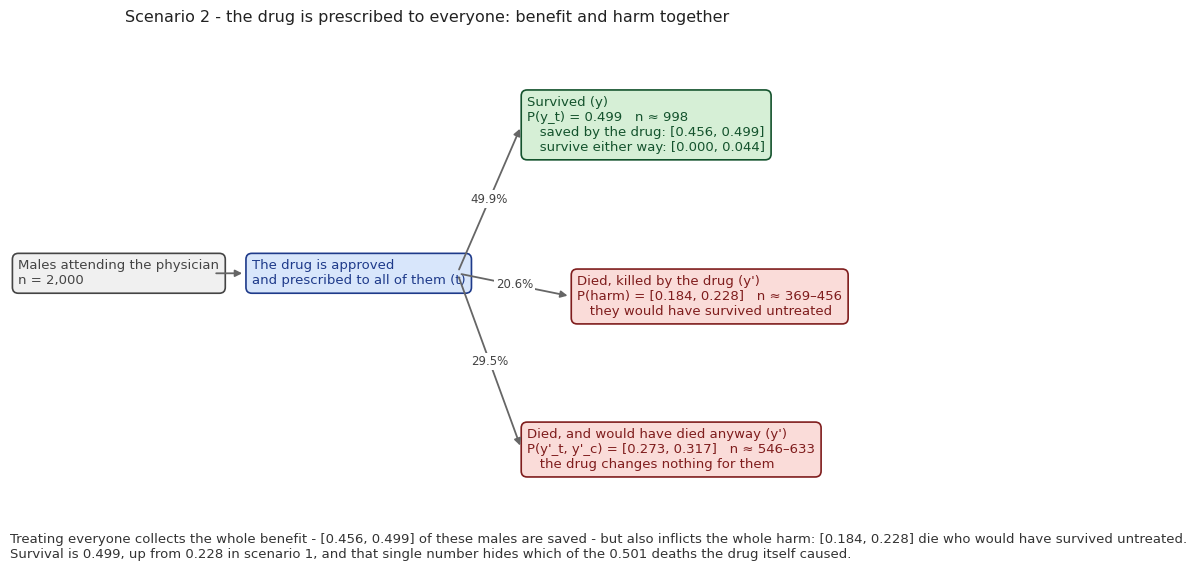

In [128]:
# Scenario 2 - the drug is approved and prescribed to every male who attends (t).
plot_prescribed_to_all(male_types, n=MALE_SAMPLE, tol=e)

### Scenario 3 - the physician prescribes by biomarker

The males attend the physician, who reads each one's biomarker: the drug is
prescribed to everyone it would not harm and withheld from those it would.
Three groups come out of that split - of the males who take the drug, some
survive and some die, while every male kept off it survives. Harm disappears
and the benefit is kept, so survival becomes $P(y_t) + P(harm)$.

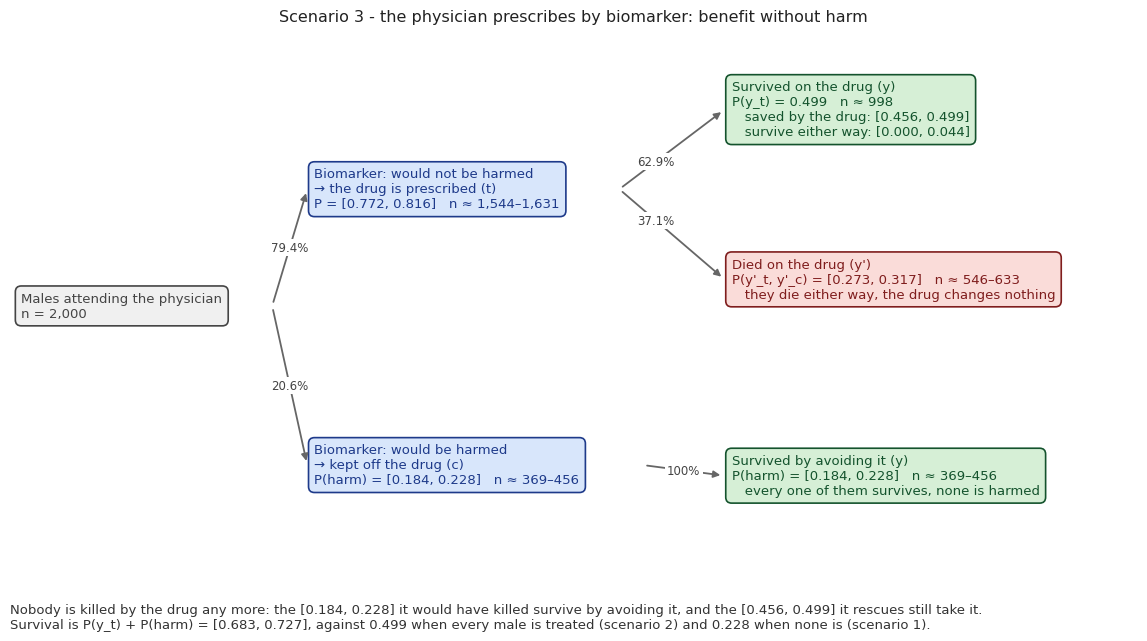

In [36]:
# Scenario 3 - the biomarker tells the physician which males the drug would harm.
plot_biomarker(male_types, n=MALE_SAMPLE, tol=e)